In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import torch 
import torchvision 
from torchvision import transforms, datasets
import os 
from PIL import Image, UnidentifiedImageError
from collections import Counter
import random
import torch.nn as nn 
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.metrics import (roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, balanced_accuracy_score)

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Preprocessing

In [3]:
# preprocessing only, no normalization yet
base_transform_no_norm = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_dataset_no_norm = datasets.ImageFolder(
    root='data_project_gray/train',
    transform=base_transform_no_norm
)

def compute_mean_std(dataset):
    pixel_sum = 0.0
    pixel_squared_sum = 0.0
    total_pixels = 0
    valid_images = 0

    for i in range(len(dataset)):
        try:
            image, _ = dataset[i]
            pixel_sum += image.sum().item()
            pixel_squared_sum += (image ** 2).sum().item()
            total_pixels += image.numel()
            valid_images += 1
        except (UnidentifiedImageError, OSError):
            print(f"Skipping corrupted image at index {i}")
            continue

    mean = pixel_sum / total_pixels
    std = ((pixel_squared_sum / total_pixels) - mean**2) ** 0.5

    print("Valid training images used:", valid_images)
    print("Training mean:", round(mean, 4))
    print("Training std:", round(std, 4))

    return mean, std

train_mean, train_std = compute_mean_std(train_dataset_no_norm)

Skipping corrupted image at index 381
Valid training images used: 749
Training mean: 0.606
Training std: 0.1944


In [4]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    
    # augmentation
    transforms.RandomRotation(degrees=10, fill=0),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        fill=0
    ),
    
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std])
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std])
])

In [5]:
train_dataset = datasets.ImageFolder(
    root='data_project_gray/train',
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root='data_project_gray/val',
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root='data_project_gray/test',
    transform=eval_transform
)

In [6]:
from torch.utils.data import Dataset
from PIL import UnidentifiedImageError

class SafeImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.dataset = datasets.ImageFolder(root=root, transform=transform)
        self.transform = transform
        # filter out corrupted images
        self.valid_indices = []
        for i in range(len(self.dataset)):
            path, _ = self.dataset.samples[i]
            try:
                with open(path, 'rb') as f:
                    Image.open(f).verify()
                self.valid_indices.append(i)
            except (UnidentifiedImageError, OSError):
                print(f"Skipping corrupted image: {path}")

        self.classes = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx
        self.targets = [self.dataset.targets[i] for i in self.valid_indices]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        return self.dataset[self.valid_indices[idx]]

In [7]:
train_dataset = SafeImageFolder(root='data_project_gray/train', transform=train_transform)
val_dataset   = SafeImageFolder(root='data_project_gray/val',   transform=eval_transform)
test_dataset  = SafeImageFolder(root='data_project_gray/test',  transform=eval_transform)

Skipping corrupted image: data_project_gray/train\0\9184495L.png
Skipping corrupted image: data_project_gray/val\1\9294761L.png


In [8]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [9]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Min pixel value:", images.min().item())
print("Max pixel value:", images.max().item())

Batch image shape: torch.Size([32, 1, 128, 128])
Batch labels shape: torch.Size([32])
Min pixel value: -3.1172120571136475
Max pixel value: 1.9458329677581787


In [ ]:
train_labels = torch.tensor(train_dataset.targets)
n_neg = (train_labels == 0).sum().item()  # Healthy
n_pos = (train_labels == 1).sum().item()  # OA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float).to(device)
print(f"pos_weight: {pos_weight.item():.2f}")


Using device: cpu
pos_weight: 2.00


# Baseline model

### Model architecture

In [ ]:
class Baseline(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()

        # convolution part 
        self.conv = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                               

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                             

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                             
        )

        # connected part 
        self.conn = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self,x):
        return self.conn(self.conv(x)).squeeze(1)
    
device = torch.device("cpu")
model = Baseline(dropout=0.5).to(device)
print(model) 
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Baseline(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conn): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, i

In [ ]:
class Baseline2(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()

        # convolution part 
        self.conv = nn.Sequential(
            # Block 1
            # Block 1
            nn.Conv2d(1, 16, kernel_size=3, padding=1), 
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2), # Output: (16, 64, 64)

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), # Output: (32, 32, 32)                            # -> (128,16,16)
        )

        # connected part 
        self.conn = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self,x):
        return self.conn(self.conv(x)).squeeze()
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2 = Baseline2(dropout=0.5).to(device)
print(model2) 
print(f"\nTrainable parameters: {sum(p.numel() for p in model2.parameters() if p.requires_grad):,}")

Baseline2(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conn): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)

Trainable parameters: 8,394,017


In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def calculate_metrics(loader, model, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            logits = model(X)
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y.numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds  = (all_probs >= threshold).astype(int)

    return {
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall":    recall_score(all_labels, all_preds, zero_division=0),
        "f1":        f1_score(all_labels, all_preds, zero_division=0),
        "auc":       roc_auc_score(all_labels, all_probs),
        "probs":     all_probs,
        "labels":    all_labels, 
    }

### Training the model

In [ ]:
# hyperparameters 1
# Epochs = 20, learning rate = 1e-3, weight decay = nothing, dropout = 0.5 
EPOCHS = 20 # an epoch is one complete pass of the training dataset through the neural network 
history_EP1 = {
    "train_loss":     [],
    "val_loss":       [],
    "val_precision":  [],
    "val_recall":     [],
    "val_f1":         [],
    "val_auc":        []
}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(y)
    train_loss /= len(train_dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device).float()
            val_loss += criterion(model(X), y).item() * len(y)
    val_loss /= len(val_dataset)

    metrics = calculate_metrics(val_loader, model)
    history_EP1["train_loss"].append(train_loss)
    history_EP1["val_loss"].append(val_loss)
    history_EP1["val_precision"].append(metrics["precision"])
    history_EP1["val_recall"].append(metrics["recall"])
    history_EP1["val_f1"].append(metrics["f1"])
    history_EP1["val_auc"].append(metrics["auc"])

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
      f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
      f"Prec: {metrics['precision']:.3f} | AUC: {metrics['auc']:.3f} |"
      f"Rec: {metrics['recall']:.3f} | F1: {metrics['f1']:.3f} | ")
    
    

Epoch 01/20 | Train Loss: 4.7566 | Val Loss: 1.2058 | Prec: 0.800 | AUC: 0.610 |Rec: 0.065 | F1: 0.119 | 
Epoch 02/20 | Train Loss: 1.2188 | Val Loss: 0.9751 | Prec: 0.399 | AUC: 0.601 |Rec: 0.952 | F1: 0.562 | 
Epoch 03/20 | Train Loss: 0.9278 | Val Loss: 1.0093 | Prec: 0.466 | AUC: 0.633 |Rec: 0.774 | F1: 0.582 | 
Epoch 04/20 | Train Loss: 0.9170 | Val Loss: 1.0336 | Prec: 0.403 | AUC: 0.634 |Rec: 0.935 | F1: 0.563 | 
Epoch 05/20 | Train Loss: 0.9146 | Val Loss: 1.0628 | Prec: 0.618 | AUC: 0.652 |Rec: 0.339 | F1: 0.438 | 
Epoch 06/20 | Train Loss: 0.9217 | Val Loss: 1.0178 | Prec: 0.533 | AUC: 0.651 |Rec: 0.258 | F1: 0.348 | 
Epoch 07/20 | Train Loss: 0.9125 | Val Loss: 1.0265 | Prec: 0.889 | AUC: 0.651 |Rec: 0.129 | F1: 0.225 | 
Epoch 08/20 | Train Loss: 0.9100 | Val Loss: 0.9953 | Prec: 0.519 | AUC: 0.658 |Rec: 0.645 | F1: 0.576 | 
Epoch 09/20 | Train Loss: 0.8945 | Val Loss: 1.0166 | Prec: 0.609 | AUC: 0.668 |Rec: 0.226 | F1: 0.329 | 
Epoch 10/20 | Train Loss: 0.8948 | Val Loss: 1

In [ ]:
# EPOCHS experiment 2
EPOCHS = 30 
history_EP2 = {
    "train_loss":     [],
    "val_loss":       [],
    "val_precision":  [],
    "val_recall":     [],
    "val_f1":         [],
    "val_auc":        []
}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for X, y in train_loader: 
        X, y = X.to(device), y.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(X), y) 
        loss.backward()
        optimizer.step() 
        train_loss += loss.item() * len(y)
    train_loss /= len(train_dataset) 

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device).float()
            val_loss += criterion(model(X), y).item() * len(y)
    val_loss /= len(val_dataset)

    metrics = calculate_metrics(val_loader, model)
    history_EP2["train_loss"].append(train_loss)
    history_EP2["val_loss"].append(val_loss)
    history_EP2["val_precision"].append(metrics["precision"])
    history_EP2["val_recall"].append(metrics["recall"])
    history_EP2["val_f1"].append(metrics["f1"])
    history_EP2["val_auc"].append(metrics["auc"])

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
      f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
      f"Prec: {metrics['precision']:.3f} | AUC: {metrics['auc']:.3f} |"
      f"Rec: {metrics['recall']:.3f} | F1: {metrics['f1']:.3f} | ")

Epoch 01/30 | Train Loss: 1.2550 | Val Loss: 0.9749 | Prec: 0.818 | AUC: 0.726 |Rec: 0.145 | F1: 0.247 | 
Epoch 02/30 | Train Loss: 0.9126 | Val Loss: 0.8970 | Prec: 0.485 | AUC: 0.697 |Rec: 0.790 | F1: 0.601 | 
Epoch 03/30 | Train Loss: 0.8824 | Val Loss: 0.8878 | Prec: 0.447 | AUC: 0.682 |Rec: 0.742 | F1: 0.558 | 
Epoch 04/30 | Train Loss: 0.8632 | Val Loss: 0.8694 | Prec: 0.644 | AUC: 0.727 |Rec: 0.613 | F1: 0.628 | 
Epoch 05/30 | Train Loss: 0.8312 | Val Loss: 0.8672 | Prec: 0.750 | AUC: 0.778 |Rec: 0.484 | F1: 0.588 | 
Epoch 06/30 | Train Loss: 0.8061 | Val Loss: 0.7860 | Prec: 0.667 | AUC: 0.797 |Rec: 0.710 | F1: 0.688 | 
Epoch 07/30 | Train Loss: 0.7619 | Val Loss: 0.8342 | Prec: 0.811 | AUC: 0.843 |Rec: 0.484 | F1: 0.606 | 
Epoch 08/30 | Train Loss: 0.7125 | Val Loss: 0.7705 | Prec: 0.736 | AUC: 0.826 |Rec: 0.629 | F1: 0.678 | 
Epoch 09/30 | Train Loss: 0.6711 | Val Loss: 0.6825 | Prec: 0.782 | AUC: 0.862 |Rec: 0.694 | F1: 0.735 | 
Epoch 10/30 | Train Loss: 0.6130 | Val Loss: 0

C:\Users\julie\AppData\Local\Temp\ipykernel_29216\451025106.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].set_title("AUC"); axes[1, 2].legend()
C:\Users\julie\AppData\Local\Temp\ipykernel_29216\451025106.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].set_title("AUC"); axes[1, 2].legend()


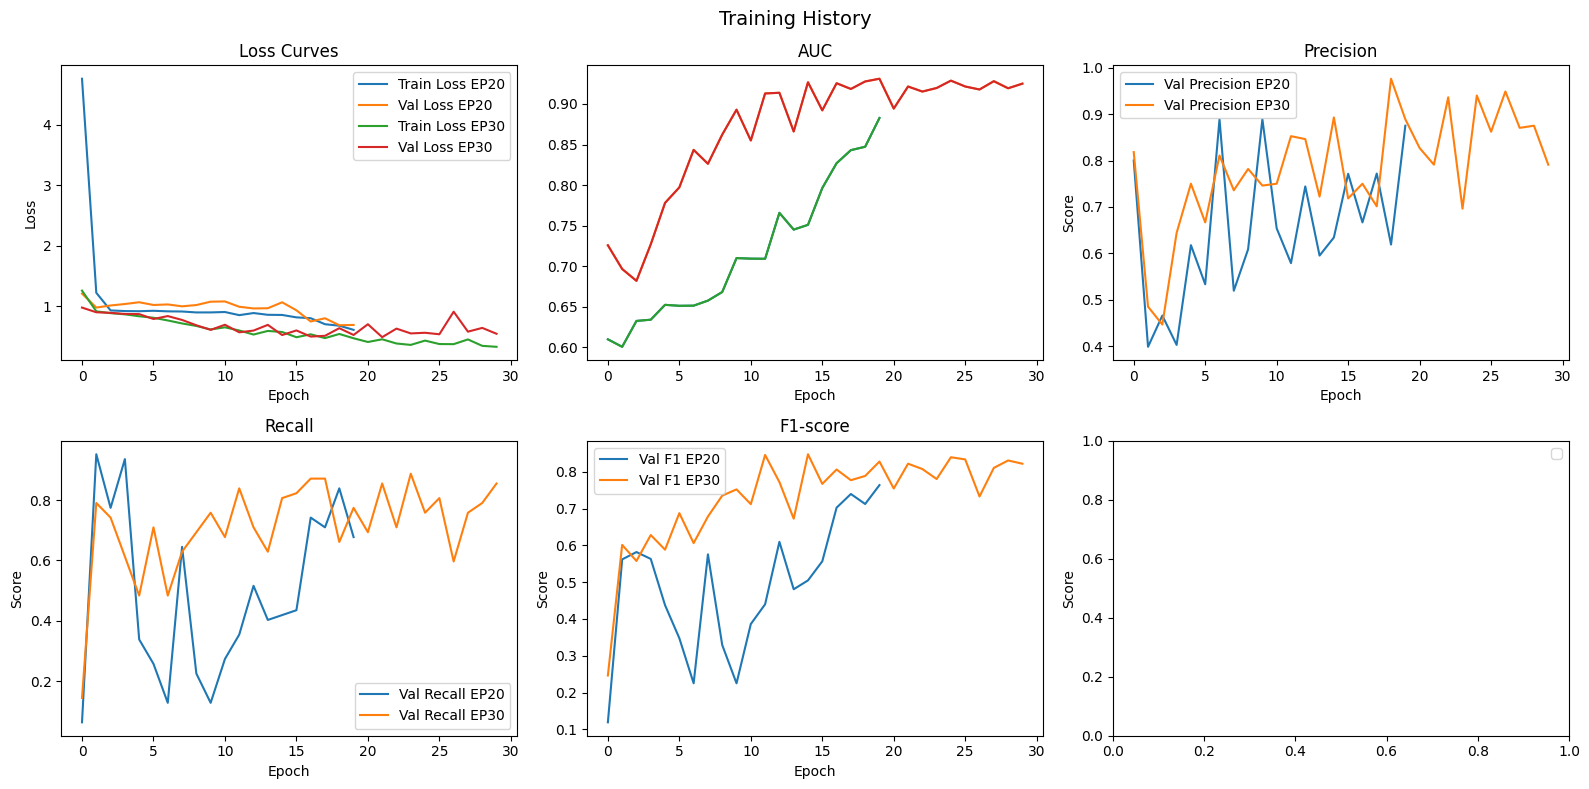

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].plot(history_EP1["train_loss"], label="Train Loss EP20")
axes[0, 0].plot(history_EP1["val_loss"],   label="Val Loss EP20")
axes[0, 0].plot(history_EP2["train_loss"], label="Train Loss EP30")
axes[0, 0].plot(history_EP2["val_loss"],   label="Val Loss EP30")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Loss Curves"); axes[0, 0].legend()

axes[0, 1].plot(history_EP1["val_auc"], label="Val AUC EP20")
axes[0, 1].plot(history_EP2["val_auc"], label="Val AUC EP30")
axes[0, 1].set_xlabel("Epoch"); axes[1, 2].set_ylabel("Score")
axes[0, 1].set_title("AUC"); axes[1, 2].legend()

axes[0, 2].plot(history_EP1["val_precision"], label="Val Precision EP20")
axes[0, 2].plot(history_EP2["val_precision"], label="Val Precision EP30")
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("Score")
axes[0, 2].set_title("Precision"); axes[0, 2].legend()

axes[1, 0].plot(history_EP1["val_recall"], label="Val Recall EP20")
axes[1, 0].plot(history_EP2["val_recall"], label="Val Recall EP30")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Score")
axes[1, 0].set_title("Recall"); axes[1, 0].legend()

axes[1, 1].plot(history_EP1["val_f1"], label="Val F1 EP20")
axes[1, 1].plot(history_EP2["val_f1"], label="Val F1 EP30")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Score")
axes[1, 1].set_title("F1-score"); axes[1, 1].legend()


plt.suptitle("Training History", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# dropout experiment 1 
# dropout = 0.5
EPOCHS = 30
history_D1 = {
    "train_loss":     [],
    "val_loss":       [],
    "val_precision":  [],
    "val_recall":     [],
    "val_f1":         [],
    "val_auc":        []
}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(X), y) 
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(y)
    train_loss /= len(train_dataset) 

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device).float()
            val_loss += criterion(model(X), y).item() * len(y)
    val_loss /= len(val_dataset)

    metrics = calculate_metrics(val_loader, model)
    history_D1["train_loss"].append(train_loss)
    history_D1["val_loss"].append(val_loss)
    history_D1["val_precision"].append(metrics["precision"])
    history_D1["val_recall"].append(metrics["recall"])
    history_D1["val_f1"].append(metrics["f1"])
    history_D1["val_auc"].append(metrics["auc"])

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
      f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
      f"Prec: {metrics['precision']:.3f} | AUC: {metrics['auc']:.3f} |"
      f"Rec: {metrics['recall']:.3f} | F1: {metrics['f1']:.3f} | ")

Epoch 01/30 | Train Loss: 3.1701 | Val Loss: 1.0184 | Prec: 0.818 | AUC: 0.661 |Rec: 0.145 | F1: 0.247 | 
Epoch 02/30 | Train Loss: 1.0444 | Val Loss: 0.9636 | Prec: 1.000 | AUC: 0.690 |Rec: 0.065 | F1: 0.121 | 
Epoch 03/30 | Train Loss: 0.9221 | Val Loss: 0.9503 | Prec: 0.632 | AUC: 0.686 |Rec: 0.387 | F1: 0.480 | 
Epoch 04/30 | Train Loss: 0.9091 | Val Loss: 0.9439 | Prec: 0.610 | AUC: 0.689 |Rec: 0.403 | F1: 0.485 | 
Epoch 05/30 | Train Loss: 0.9064 | Val Loss: 0.9357 | Prec: 0.585 | AUC: 0.692 |Rec: 0.387 | F1: 0.466 | 
Epoch 06/30 | Train Loss: 0.8870 | Val Loss: 0.9031 | Prec: 0.600 | AUC: 0.698 |Rec: 0.581 | F1: 0.590 | 
Epoch 07/30 | Train Loss: 0.8814 | Val Loss: 0.8910 | Prec: 0.596 | AUC: 0.699 |Rec: 0.548 | F1: 0.571 | 
Epoch 08/30 | Train Loss: 0.8547 | Val Loss: 0.8551 | Prec: 0.580 | AUC: 0.755 |Rec: 0.758 | F1: 0.657 | 
Epoch 09/30 | Train Loss: 0.8538 | Val Loss: 0.8617 | Prec: 0.667 | AUC: 0.760 |Rec: 0.484 | F1: 0.561 | 
Epoch 10/30 | Train Loss: 0.8569 | Val Loss: 0

In [ ]:
# dropout experiment 1 
# dropout = 0.2 
EPOCHS = 30
history_D2 = {
    "train_loss":     [],
    "val_loss":       [],
    "val_precision":  [],
    "val_recall":     [],
    "val_f1":         [],
    "val_auc":        []
}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for X, y in train_loader: 
        X, y = X.to(device), y.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(X), y) 
        loss.backward() 
        optimizer.step()
        train_loss += loss.item() * len(y)
    train_loss /= len(train_dataset) 

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device).float()
            val_loss += criterion(model(X), y).item() * len(y)
    val_loss /= len(val_dataset)

    metrics = calculate_metrics(val_loader, model)
    history_D2["train_loss"].append(train_loss)
    history_D2["val_loss"].append(val_loss)
    history_D2["val_precision"].append(metrics["precision"])
    history_D2["val_recall"].append(metrics["recall"])
    history_D2["val_f1"].append(metrics["f1"])
    history_D2["val_auc"].append(metrics["auc"])

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
      f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
      f"Prec: {metrics['precision']:.3f} | AUC: {metrics['auc']:.3f} |"
      f"Rec: {metrics['recall']:.3f} | F1: {metrics['f1']:.3f} | ")

Epoch 01/30 | Train Loss: 3.2875 | Val Loss: 0.8674 | Prec: 0.548 | AUC: 0.725 |Rec: 0.548 | F1: 0.548 | 
Epoch 02/30 | Train Loss: 1.1172 | Val Loss: 0.8758 | Prec: 0.539 | AUC: 0.710 |Rec: 0.661 | F1: 0.594 | 
Epoch 03/30 | Train Loss: 0.9354 | Val Loss: 0.8962 | Prec: 0.454 | AUC: 0.676 |Rec: 0.871 | F1: 0.597 | 
Epoch 04/30 | Train Loss: 0.8929 | Val Loss: 0.8856 | Prec: 0.484 | AUC: 0.683 |Rec: 0.726 | F1: 0.581 | 
Epoch 05/30 | Train Loss: 0.8987 | Val Loss: 0.8973 | Prec: 0.563 | AUC: 0.702 |Rec: 0.645 | F1: 0.602 | 
Epoch 06/30 | Train Loss: 0.8400 | Val Loss: 0.8567 | Prec: 0.581 | AUC: 0.750 |Rec: 0.694 | F1: 0.632 | 
Epoch 07/30 | Train Loss: 0.7818 | Val Loss: 0.8988 | Prec: 0.769 | AUC: 0.791 |Rec: 0.323 | F1: 0.455 | 
Epoch 08/30 | Train Loss: 0.6765 | Val Loss: 0.9028 | Prec: 0.800 | AUC: 0.797 |Rec: 0.516 | F1: 0.627 | 
Epoch 09/30 | Train Loss: 0.6729 | Val Loss: 0.9155 | Prec: 0.842 | AUC: 0.816 |Rec: 0.516 | F1: 0.640 | 
Epoch 10/30 | Train Loss: 0.6740 | Val Loss: 0

In [ ]:
# dropout experiment 3
# dropout = 0.7
EPOCHS = 30
history_D3 = {
    "train_loss":     [],
    "val_loss":       [],
    "val_precision":  [],
    "val_recall":     [],
    "val_f1":         [],
    "val_auc":        []
}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for X, y in train_loader: 
        X, y = X.to(device), y.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(X), y) 
        loss.backward() 
        optimizer.step()
        train_loss += loss.item() * len(y)
    train_loss /= len(train_dataset) 

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device).float()
            val_loss += criterion(model(X), y).item() * len(y)
    val_loss /= len(val_dataset)

    metrics = calculate_metrics(val_loader, model)
    history_D3["train_loss"].append(train_loss)
    history_D3["val_loss"].append(val_loss)
    history_D3["val_precision"].append(metrics["precision"])
    history_D3["val_recall"].append(metrics["recall"])
    history_D3["val_f1"].append(metrics["f1"])
    history_D3["val_auc"].append(metrics["auc"])

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
      f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
      f"Prec: {metrics['precision']:.3f} | AUC: {metrics['auc']:.3f} |"
      f"Rec: {metrics['recall']:.3f} | F1: {metrics['f1']:.3f} | ")

Epoch 01/30 | Train Loss: 7.0298 | Val Loss: 1.6245 | Prec: 0.357 | AUC: 0.503 |Rec: 0.645 | F1: 0.460 | 
Epoch 02/30 | Train Loss: 1.3887 | Val Loss: 1.0020 | Prec: 0.533 | AUC: 0.556 |Rec: 0.387 | F1: 0.449 | 
Epoch 03/30 | Train Loss: 0.9236 | Val Loss: 1.0292 | Prec: 0.492 | AUC: 0.600 |Rec: 0.468 | F1: 0.479 | 
Epoch 04/30 | Train Loss: 0.9224 | Val Loss: 1.0254 | Prec: 0.479 | AUC: 0.613 |Rec: 0.565 | F1: 0.519 | 
Epoch 05/30 | Train Loss: 0.9184 | Val Loss: 1.0700 | Prec: 1.000 | AUC: 0.617 |Rec: 0.048 | F1: 0.092 | 
Epoch 06/30 | Train Loss: 0.9173 | Val Loss: 1.0442 | Prec: 0.857 | AUC: 0.599 |Rec: 0.097 | F1: 0.174 | 
Epoch 07/30 | Train Loss: 0.9086 | Val Loss: 1.0645 | Prec: 0.561 | AUC: 0.590 |Rec: 0.371 | F1: 0.447 | 
Epoch 08/30 | Train Loss: 0.9225 | Val Loss: 1.0987 | Prec: 0.583 | AUC: 0.614 |Rec: 0.452 | F1: 0.509 | 
Epoch 09/30 | Train Loss: 0.9110 | Val Loss: 1.0769 | Prec: 0.596 | AUC: 0.633 |Rec: 0.500 | F1: 0.544 | 
Epoch 10/30 | Train Loss: 0.9025 | Val Loss: 1

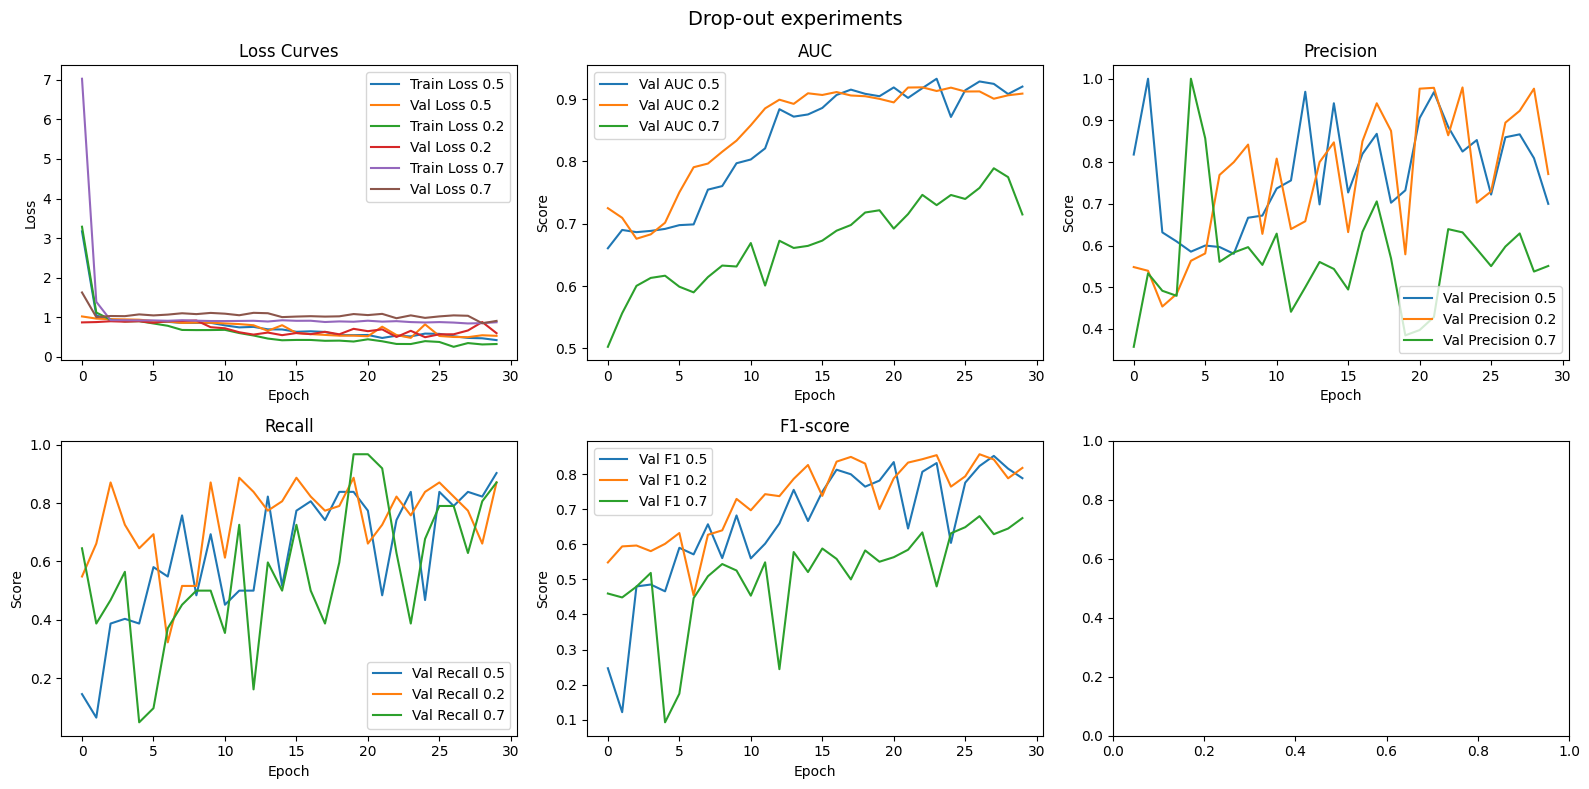

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].plot(history_D1["train_loss"], label="Train Loss 0.5")
axes[0, 0].plot(history_D1["val_loss"],   label="Val Loss 0.5")
axes[0, 0].plot(history_D2["train_loss"], label="Train Loss 0.2")
axes[0, 0].plot(history_D2["val_loss"],   label="Val Loss 0.2")
axes[0, 0].plot(history_D3["train_loss"], label="Train Loss 0.7")
axes[0, 0].plot(history_D3["val_loss"],   label="Val Loss 0.7")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Loss Curves"); axes[0, 0].legend()

axes[0, 1].plot(history_D1["val_auc"], label="Val AUC 0.5")
axes[0, 1].plot(history_D2["val_auc"], label="Val AUC 0.2")
axes[0, 1].plot(history_D3["val_auc"], label="Val AUC 0.7")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Score")
axes[0, 1].set_title("AUC"); axes[0, 1].legend()

axes[0, 2].plot(history_D1["val_precision"], label="Val Precision 0.5")
axes[0, 2].plot(history_D2["val_precision"], label="Val Precision 0.2")
axes[0, 2].plot(history_D3["val_precision"], label="Val Precision 0.7")
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("Score")
axes[0, 2].set_title("Precision"); axes[0, 2].legend()

axes[1, 0].plot(history_D1["val_recall"], label="Val Recall 0.5")
axes[1, 0].plot(history_D2["val_recall"], label="Val Recall 0.2")
axes[1, 0].plot(history_D3["val_recall"], label="Val Recall 0.7")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Score")
axes[1, 0].set_title("Recall"); axes[1, 0].legend()

axes[1, 1].plot(history_D1["val_f1"], label="Val F1 0.5")
axes[1, 1].plot(history_D2["val_f1"], label="Val F1 0.2")
axes[1, 1].plot(history_D3["val_f1"], label="Val F1 0.7")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Score")
axes[1, 1].set_title("F1-score"); axes[1, 1].legend()

plt.suptitle("Drop-out experiments", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# hyperparameters 3
# Epochs = 30, learning rate = 1e-3, weight decay = nothing, dropout = 0.5 
# this is a test with a simpler model with less parameters (maybe help with overfitting) 
EPOCHS = 30 # an epoch is one complete pass of the training dataset through the neural network 
history = {
    "train_loss":     [],
    "val_loss":       [],
    "val_accuracy":   [],
    "val_precision":  [],
    "val_recall":     [],
    "val_f1":         [],
    "val_auc":        []
}

for epoch in range(1, EPOCHS + 1):
    model2.train()
    train_loss = 0.0
    for X, y in train_loader: # the loader divides the big dataset into batches, otherwise too much data at once 
        X, y = X.to(device), y.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model2(X), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(y)
    train_loss /= len(train_dataset)

    # validate
    model2.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device).float()
            val_loss += criterion(model2(X), y).item() * len(y)
    val_loss /= len(val_dataset)

    metrics = calculate_metrics(val_loader, model2)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(metrics["accuracy"])
    history["val_precision"].append(metrics["precision"])
    history["val_recall"].append(metrics["recall"])
    history["val_f1"].append(metrics["f1"])
    history["val_auc"].append(metrics["auc"])

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
      f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
      f"Acc: {metrics['accuracy']:.3f} | Prec: {metrics['precision']:.3f} | "
      f"Rec: {metrics['recall']:.3f} | F1: {metrics['f1']:.3f} | "
      f"AUC: {metrics['auc']:.3f}")
    

Epoch 01/30 | Train Loss: 5.9086 | Val Loss: 1.3424 | Acc: 0.500 | Prec: 0.422 | Rec: 0.742 | F1: 0.538 | AUC: 0.653
Epoch 02/30 | Train Loss: 1.4871 | Val Loss: 0.8715 | Acc: 0.734 | Prec: 0.667 | Rec: 0.645 | F1: 0.656 | AUC: 0.762
Epoch 03/30 | Train Loss: 0.8897 | Val Loss: 0.9182 | Acc: 0.677 | Prec: 0.634 | Rec: 0.419 | F1: 0.505 | AUC: 0.724
Epoch 04/30 | Train Loss: 0.8584 | Val Loss: 0.9021 | Acc: 0.658 | Prec: 0.543 | Rec: 0.823 | F1: 0.654 | AUC: 0.737
Epoch 05/30 | Train Loss: 0.8645 | Val Loss: 0.8708 | Acc: 0.684 | Prec: 0.586 | Rec: 0.661 | F1: 0.621 | AUC: 0.741
Epoch 06/30 | Train Loss: 0.8384 | Val Loss: 0.8927 | Acc: 0.671 | Prec: 0.561 | Rec: 0.742 | F1: 0.639 | AUC: 0.727
Epoch 07/30 | Train Loss: 0.8455 | Val Loss: 0.8538 | Acc: 0.709 | Prec: 0.611 | Rec: 0.710 | F1: 0.657 | AUC: 0.749
Epoch 08/30 | Train Loss: 0.8238 | Val Loss: 0.8113 | Acc: 0.722 | Prec: 0.661 | Rec: 0.597 | F1: 0.627 | AUC: 0.783
Epoch 09/30 | Train Loss: 0.7988 | Val Loss: 0.8059 | Acc: 0.696

On the graph below we can see that because we removed some of the layers the model is clearly not as good as the first one we tried. 

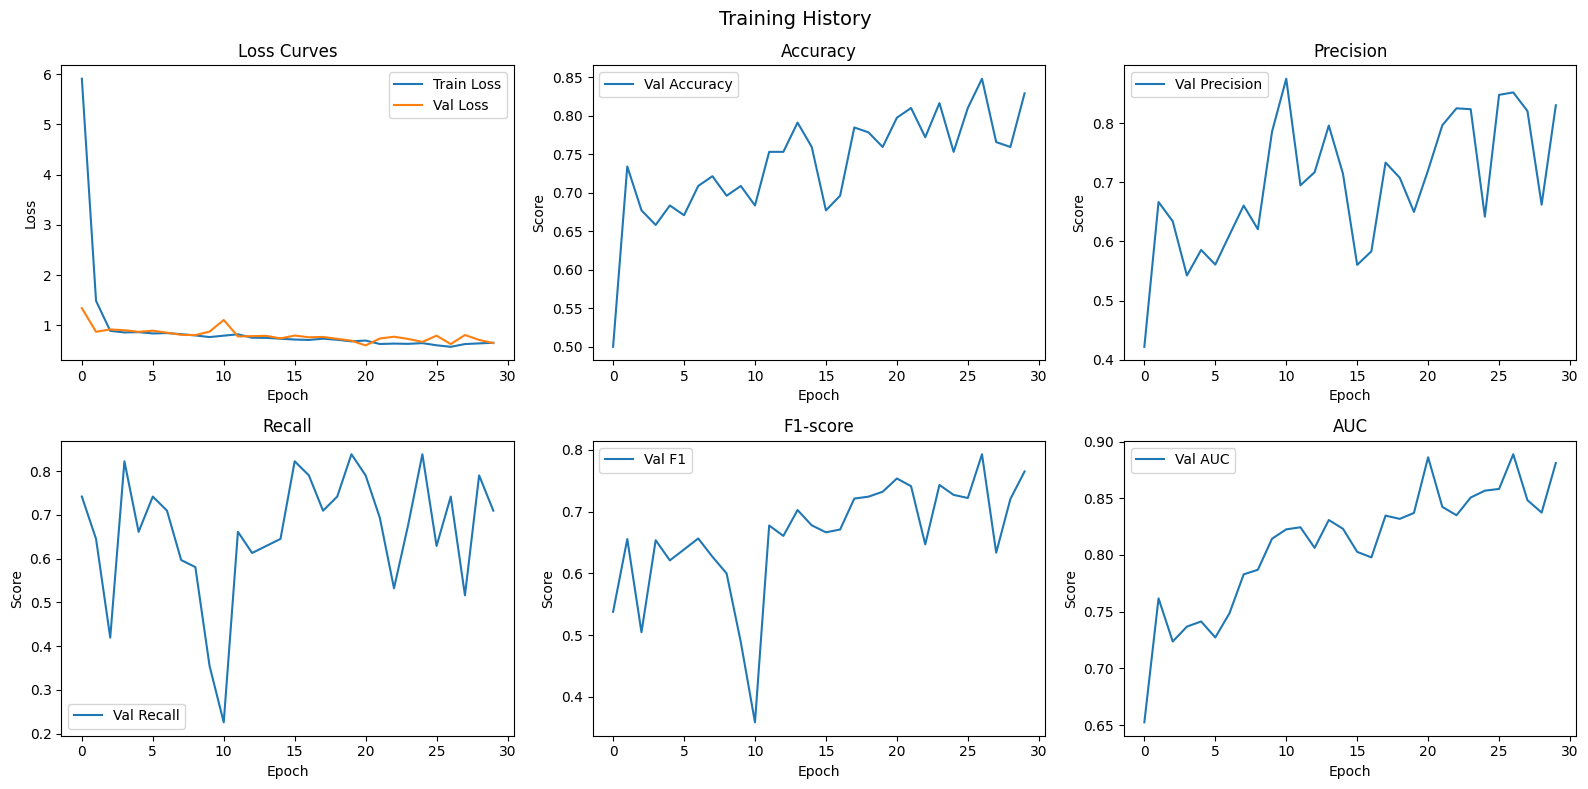

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].plot(history["train_loss"], label="Train Loss")
axes[0, 0].plot(history["val_loss"],   label="Val Loss")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Loss Curves"); axes[0, 0].legend()

axes[0, 1].plot(history["val_accuracy"], label="Val Accuracy")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Score")
axes[0, 1].set_title("Accuracy"); axes[0, 1].legend()

axes[0, 2].plot(history["val_precision"], label="Val Precision")
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("Score")
axes[0, 2].set_title("Precision"); axes[0, 2].legend()

axes[1, 0].plot(history["val_recall"], label="Val Recall")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Score")
axes[1, 0].set_title("Recall"); axes[1, 0].legend()

axes[1, 1].plot(history["val_f1"], label="Val F1")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Score")
axes[1, 1].set_title("F1-score"); axes[1, 1].legend()

axes[1, 2].plot(history["val_auc"], label="Val AUC")
axes[1, 2].set_xlabel("Epoch"); axes[1, 2].set_ylabel("Score")
axes[1, 2].set_title("AUC"); axes[1, 2].legend()

plt.suptitle("Training History", fontsize=14)
plt.tight_layout()
plt.show()

## final baseline

#### chosen hyperparameters
dropout rate: 0.5

learning rate: 0.0001

optimizer: Adam

loss function: BCEWithLogitsLoss

#### chosen metrics
F1-score, precision, recall, area under the curve 

Epoch 01/30 | Train Loss: 4.3342
Epoch 02/30 | Train Loss: 0.9751
Epoch 03/30 | Train Loss: 0.9187
Epoch 04/30 | Train Loss: 0.9133
Epoch 05/30 | Train Loss: 0.8936
Epoch 06/30 | Train Loss: 0.9008
Epoch 07/30 | Train Loss: 0.8901
Epoch 08/30 | Train Loss: 0.8607
Epoch 09/30 | Train Loss: 0.8543
Epoch 10/30 | Train Loss: 0.8394
Epoch 11/30 | Train Loss: 0.7773
Epoch 12/30 | Train Loss: 0.7995
Epoch 13/30 | Train Loss: 0.7820
Epoch 14/30 | Train Loss: 0.7761
Epoch 15/30 | Train Loss: 0.6922
Epoch 16/30 | Train Loss: 0.6762
Epoch 17/30 | Train Loss: 0.6784
Epoch 18/30 | Train Loss: 0.6179
Epoch 19/30 | Train Loss: 0.6484
Epoch 20/30 | Train Loss: 0.6582
Epoch 21/30 | Train Loss: 0.5909
Epoch 22/30 | Train Loss: 0.5299
Epoch 23/30 | Train Loss: 0.5488
Epoch 24/30 | Train Loss: 0.5191
Epoch 25/30 | Train Loss: 0.5501
Epoch 26/30 | Train Loss: 0.4960
Epoch 27/30 | Train Loss: 0.4945
Epoch 28/30 | Train Loss: 0.4392
Epoch 29/30 | Train Loss: 0.4749
Epoch 30/30 | Train Loss: 0.4422


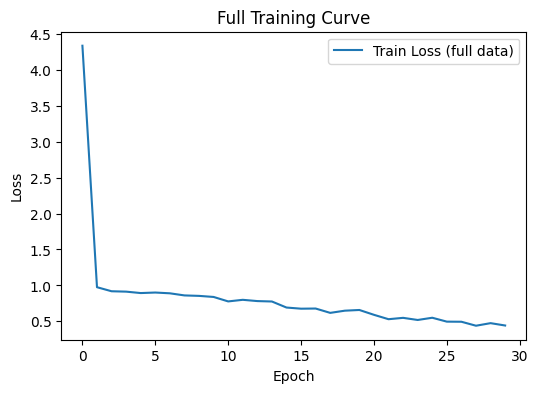

In [42]:
full_train_dataset = ConcatDataset([train_dataset, val_dataset])
full_train_loader  = DataLoader(full_train_dataset, batch_size=32, shuffle=True)

# Re-initialise model — important!
model = Baseline(dropout=0.5).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

full_history = {"train_loss": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for X, y in full_train_loader:
        X, y = X.to(device), y.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(y)
    train_loss /= len(full_train_dataset)
    full_history["train_loss"].append(train_loss)
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(full_history["train_loss"], label="Train Loss (full data)")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Full Training Curve"); plt.legend()
plt.show()

In [43]:
torch.save(model.state_dict(), "baseline_model.pth")

model_loaded = Baseline(dropout=0.5).to(device)
model_loaded.load_state_dict(torch.load("baseline_model.pth", map_location=device))
model_loaded.eval()
print("Model saved and reloaded successfully.")

Model saved and reloaded successfully.


In [44]:
metrics = calculate_metrics(test_loader, model_loaded)
test_labels = metrics["labels"]
test_probs = metrics["probs"]
ROC = metrics["auc" ]
print(f"Test Precision:     {metrics['precision']:.4f}")
print(f"Test Recall:        {metrics['recall']:.4f}")
print(f"Test F1:            {metrics['f1']:.4f}")
print(f"Test AUC:           {metrics['auc']:.4f}")

Test Precision:     0.8305
Test Recall:        0.9800
Test F1:            0.8991
Test AUC:           0.9892


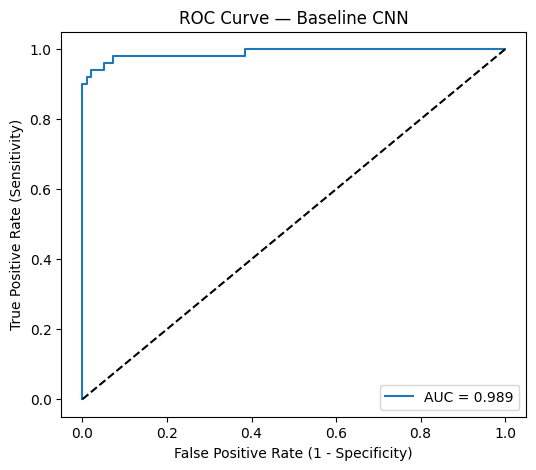

Chosen threshold: 0.920  (Sensitivity=0.900, Specificity=1.000)


In [46]:
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {ROC:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — Baseline CNN")
plt.legend()
plt.show()

# --- Threshold selection ---
# In a clinical screening context, missing an OA case (false negative) is more
# costly than a false alarm. So we prioritise high sensitivity.
# Choose the threshold where sensitivity >= 0.90.
target_sensitivity = 0.90
idx = np.where(tpr >= target_sensitivity)[0][0]
chosen_threshold = thresholds[idx]
print(f"Chosen threshold: {chosen_threshold:.3f}  "
      f"(Sensitivity={tpr[idx]:.3f}, Specificity={1-fpr[idx]:.3f})")

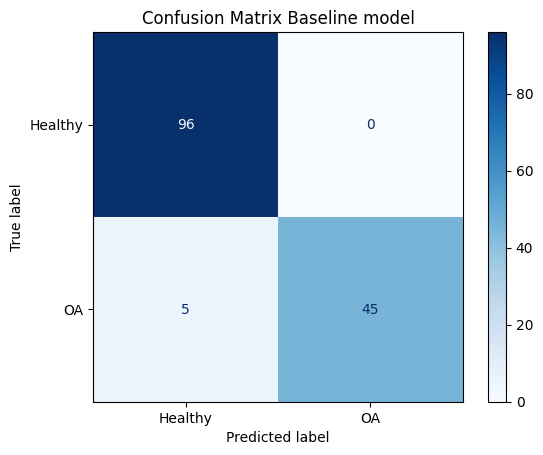

In [54]:
test_preds = (test_probs >= chosen_threshold).astype(int)
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "OA"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix Baseline model")
plt.show() 

In [48]:
def denormalize(tensor):
    """Reverse the normalization for display purposes."""
    return tensor * train_std + train_mean

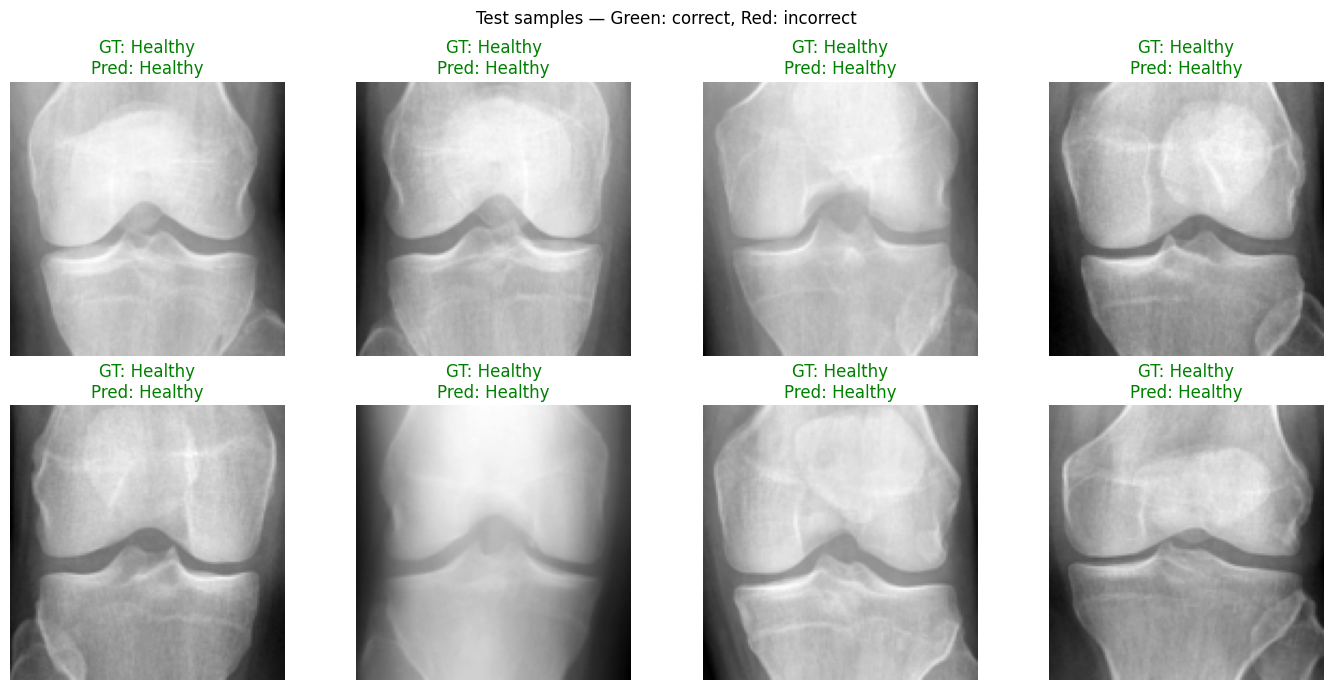

In [ ]:
# Collect a few samples from the test loader
model_loaded.eval()
samples, labels_list, preds_list = [], [], []

with torch.no_grad():
    for X, y in test_loader:
        logits = model_loaded(X.to(device))
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs >= chosen_threshold).astype(int)
        for i in range(len(X)):
            samples.append(X[i])
            labels_list.append(int(y[i]))
            preds_list.append(preds[i])
        if len(samples) >= 8:
            break

class_names = ["Healthy", "OA"]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, gt, pred in zip(axes.flat, samples, labels_list, preds_list):
    img_display = denormalize(img).squeeze().numpy()
    ax.imshow(img_display, cmap="gray")
    color = "green" if gt == pred else "red"
    ax.set_title(f"GT: {class_names[gt]}\nPred: {class_names[pred]}", color=color)
    ax.axis("off")
plt.suptitle("Test samples — Green: correct, Red: incorrect")
plt.tight_layout()
plt.show()